In [1]:
import cooler
import cooltools
import bioframe as bf
import bbi
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ggner_3d.cm import get_expected_cis_df, prepare_view_df
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score, get_insulation_fixed
from ggner_3d.dots_common import compare_loops_with_strength
from ggner_3d.bbi_helpers import stackup_bw_dict, stackup_bw_dict_q


NPROC = 8
resolution = 10000
window = 500_000
clr_ = {
    'Control': cooler.Cooler('/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394172_control_mergeRep_500bp.mcool::/resolutions/10000'),
    'Degron': cooler.Cooler('/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394173_degron_mergeRep_500bp.mcool::/resolutions/10000'),
}

# tad lengths
MAXLEN = 2e6
MINLEN = 2.5e5

rescale_flank = 1
rescale_size = 33 * (2 * rescale_flank + 1)
assert rescale_size % (2 * rescale_flank + 1) == 0 and rescale_size % 2 == 1, "rescale_size"
score_flank=rescale_flank

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import importlib
from ggner_3d import plotting
importlib.reload(plotting)
from ggner_3d.plotting import plot_flanks_start_end_stackup, lineplot_stackup_dict
plotting.update_rcparams()

In [3]:
# data paths

# Pol2

pol2_dict = {
    'dld1_pol2': ['/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/GSM5237207_IP-MinusDox1-PolII_9.bw',
                  '/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/GSM5237208_IP-MinusDox2-PolII_10.bw']
}

### TADs prep

In [4]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

insulation_table_ = [
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/control_insulation_10kb_500000_window.csv'),
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/degron_insulation_10kb_500000_window.csv'),
]

comparisons = [(0,1)]
comparisons_str = ['Control_Degron']
sample_names_str = ['Control', 'Degron']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_table_,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, clr_['Control'].bins()[:], bin_column='idx1') for df in dfs
]

tads = make_tads(dfs[0][['chrom', 'start', 'end']], maxlen=MAXLEN, minlen=MINLEN).sort_values(['chrom', 'start', 'end']).reset_index(drop=True)

Control_Degron: Preserved / Increase ::: 1653
Control_Degron: Preserved / Decrease ::: 737


In [5]:
expected_ = {
    'Control': pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/control_expected_10kb_chrom.csv'),
    'Degron': pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/degron_expected_10kb_chrom.csv'),
}

In [6]:
control_df = assign_domain_score(
                    tads,
                    clr=clr_['Control'],
                    expected=expected_['Control'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='weight',
                    rescale_flank=rescale_flank,
                    rescale_size=rescale_size,
                    score_flank=score_flank
                    ) 

degron_df = assign_domain_score(
                    tads,
                    clr=clr_['Degron'],
                    expected=expected_['Degron'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='weight',
                    rescale_flank=rescale_flank,
                    rescale_size=rescale_size,
                    score_flank=score_flank
                    )

tads_ds_merged = pd.merge(
    control_df[['chrom', 'start', 'end', 'domain_score']],
    degron_df[['chrom', 'start', 'end', 'domain_score']],
    on=['chrom', 'start', 'end'],
    suffixes=('_Control', '_Degron')
)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr8', 'chr8'): 100
INFO:coolpuppy:('chr7', 'chr7'): 111
INFO:coolpuppy:('chr5', 'chr5'): 132
INFO:coolpuppy:('chr6', 'chr6'): 126
INFO:coolpuppy:('chr4', 'chr4'): 139
INFO:coolpuppy:('chr3', 'chr3'): 147
INFO:coolpuppy:('chr1', 'chr1'): 172
INFO:coolpuppy:('chr9', 'chr9'): 90
INFO:coolpuppy:('chr2', 'chr2'): 177
INFO:coolpuppy:('chr10', 'chr10'): 87
INFO:coolpuppy:('chr16', 'chr16'): 45
INFO:coolpuppy:('chr15', 'chr15'): 73
INFO:coolpuppy:('chr12', 'chr12'): 96
INFO:coolpuppy:('chr11', 'chr11'): 110
INFO:coolpuppy:('chr14', 'chr14'): 60
INFO:coolpuppy:('chr17', 'chr17'): 52
INFO:coolpuppy:('chr21', 'chr21'): 16
INFO:coolpuppy:('chr22', 'chr22'): 27
INFO:coolpuppy:('chr13', 'chr13'): 61
INFO:coolpuppy:('chr19', 'chr19'): 43
INFO:coolpuppy:('chr18', 'chr18'): 52
INFO:coolpuppy:('chr20', 'chr20'): 58
INFO:coolpuppy:('chrX', 'chrX'): 83
INFO:coolpuppy:Total number of piled up windows: 172
INFO:coolpuppy:Resca

In [7]:
tads = tads_ds_merged.copy()

tads['ds_Q'] = pd.qcut(tads['domain_score_Degron'], q=4, labels=False) + 1

tads = tads.dropna(subset=['ds_Q']).reset_index(drop=True)
print(tads['ds_Q'].value_counts())

flank_ratio = 0.25
tads['flank_size'] = (tads['end'] - tads['start']) * flank_ratio
tads['flank_start'] = tads['start'] - tads['flank_size']
tads['flank_end'] = tads['end'] + tads['flank_size']

ds_Q
1    515
2    514
3    514
4    514
Name: count, dtype: int64


In [8]:
from ggner_3d.bbi_helpers import stackup_bw_dict_q, stackup_bw_dict

In [39]:
import importlib
from ggner_3d import bbi_helpers
importlib.reload(bbi_helpers)

nbins = 90

In [40]:
mean_per_q = False

In [ ]:
# q stackups - TADS

flank_ratio = 1
tads['length'] = tads['end'] - tads['start']
tads['flank_size'] = tads['length'] * flank_ratio
tads['flank_start'] = tads['start'] - tads['flank_size']
tads['flank_end'] = tads['end'] + tads['flank_size']

control_pol2 = stackup_bw_dict_q(
    pol2_dict["dld1_pol2"],
    tads.assign(chrom=tads["chrom"].astype(str).str.replace("chr", "", regex=False)),
    q_col="ds_Q",
    mean_per_q=mean_per_q,
    nbins=nbins,
)

### Hi-C pileups

In [12]:
# tads['chrom'] = [f'chr{chr}' for chr in tads['chrom'] if 'chr' not in chr]

pileups = {
    i: [] for i in range(1, 5)
}
from coolpuppy import coolpup

view_df = prepare_view_df(arm=False)

for i in range(1, 5):
    tads_q = tads[tads.ds_Q == i][['chrom', 'start', 'end']].reset_index(drop=True)
    # tads_q['chrom'] = [f'chr{chr}' for chr in tads_q['chrom'] if 'chr' not in chr]

    cc = coolpup.CoordCreator(tads_q, resolution=10000, features_format='bed', local=True, rescale_flank=rescale_flank)
    pup_degron = coolpup.PileUpper(clr_['Degron'], cc, expected=expected_['Degron'], view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc=6).pileupsWithControl()
    pup_control = coolpup.PileUpper(clr_['Control'], cc, expected=expected_['Control'], view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc=6).pileupsWithControl()
    pileups[i] = (pup_control, pup_degron)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6', 'chr6'): 30
INFO:coolpuppy:('chr5', 'chr5'): 22
INFO:coolpuppy:('chr4', 'chr4'): 37
INFO:coolpuppy:('chr3', 'chr3'): 39
INFO:coolpuppy:('chr1', 'chr1'): 46
INFO:coolpuppy:('chr2', 'chr2'): 54
INFO:coolpuppy:('chr7', 'chr7'): 23
INFO:coolpuppy:('chr9', 'chr9'): 27
INFO:coolpuppy:('chr8', 'chr8'): 21
INFO:coolpuppy:('chr10', 'chr10'): 26
INFO:coolpuppy:('chr11', 'chr11'): 31
INFO:coolpuppy:('chr15', 'chr15'): 17
INFO:coolpuppy:('chr14', 'chr14'): 13
INFO:coolpuppy:('chr16', 'chr16'): 4
INFO:coolpuppy:('chr12', 'chr12'): 27
INFO:coolpuppy:('chr13', 'chr13'): 11
INFO:coolpuppy:('chr17', 'chr17'): 17
INFO:coolpuppy:('chr21', 'chr21'): 4
INFO:coolpuppy:('chr19', 'chr19'): 12
INFO:coolpuppy:('chr22', 'chr22'): 10
INFO:coolpuppy:('chr20', 'chr20'): 9
INFO:coolpuppy:('chr18', 'chr18'): 12
INFO:coolpuppy:('chrX', 'chrX'): 23
INFO:coolpuppy:Total number of piled up windows: 515
INFO:coolpuppy:Rescaling with re

In [13]:
from ggner_3d.plotting import lineplot_stackup_array

In [28]:
tads.ds_Q.value_counts()

ds_Q
1    515
2    514
3    514
4    514
Name: count, dtype: int64

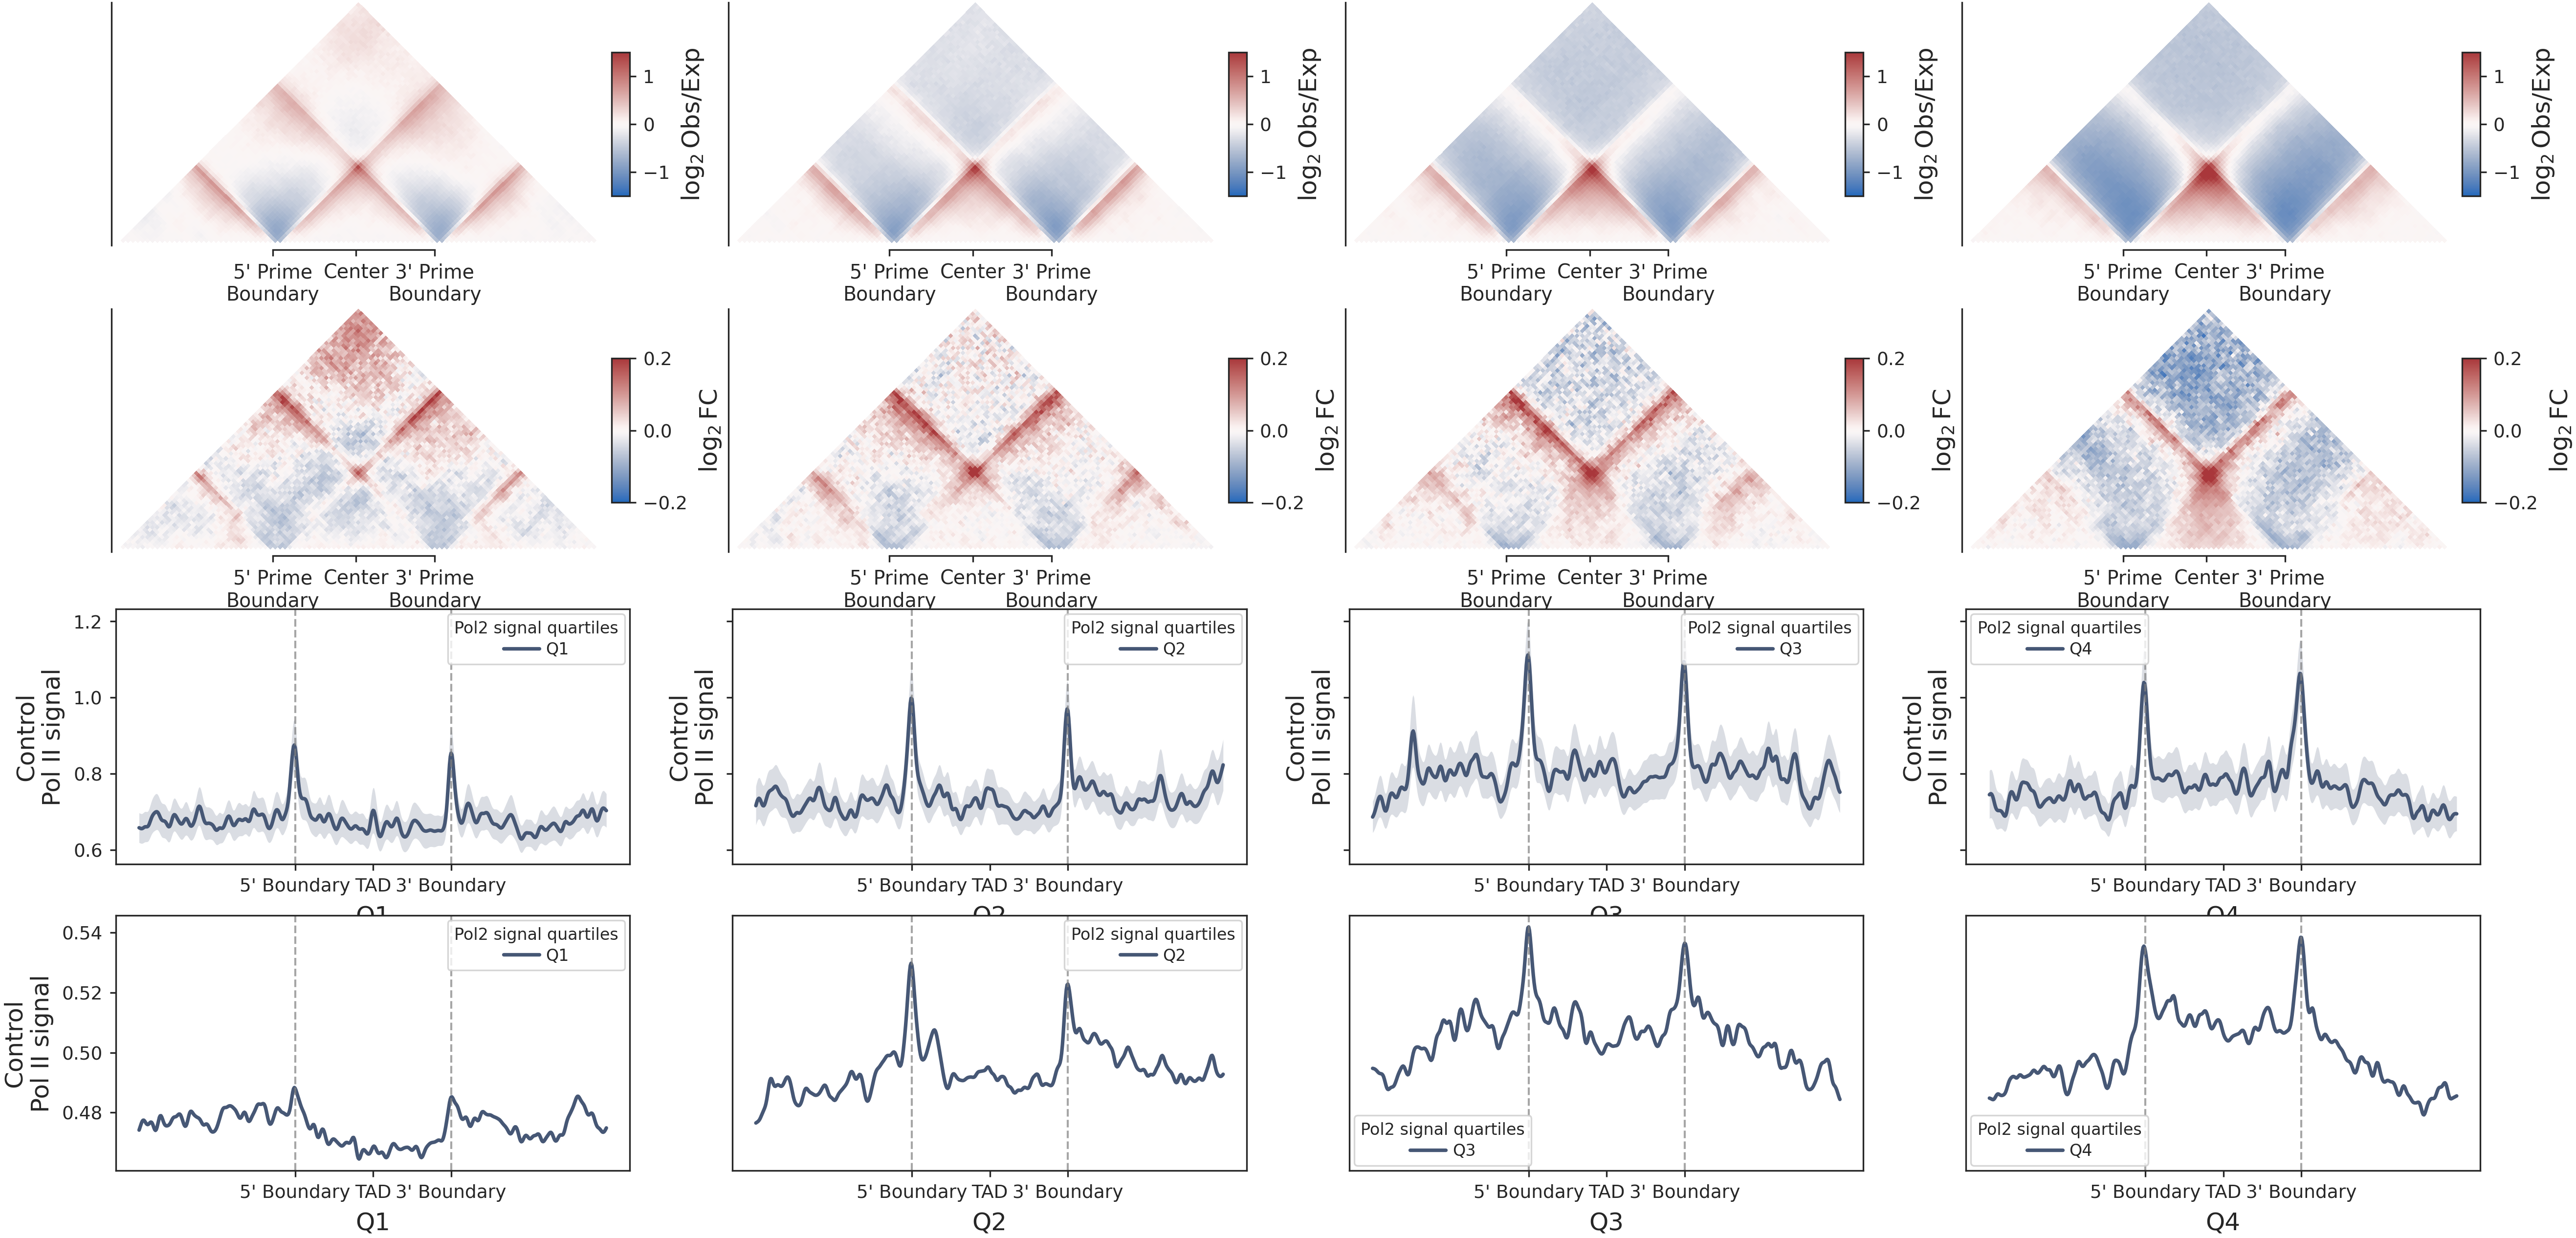

In [26]:
# two-row pileup panel
# row 1 = log2 pileups[i][0]
# row 2 = log2 fold-change = log2(pileups[i][1] / pileups[i][0])
# row 3 = chipseq

eps = 1e-6

# precompute matrices
all_base = []
all_diffs = []
for i in range(1, 5):
    base_mtx = np.log2(pileups[i][0]['data'][0] + eps)
    diff_mtx = np.log2((pileups[i][1]['data'][0] + eps) / (pileups[i][0]['data'][0] + eps))
    
    all_base.append(base_mtx)
    all_diffs.append(diff_mtx)

# color scales
base_vmin, base_vmax = -1.5, 1.5
diff_vmin, diff_vmax = -0.2, 0.2


aspect_ratio = 5.2
fig, axs = plt.subplots(4, 4, figsize=(4 * aspect_ratio, 2 * aspect_ratio), sharey='row')
plotting.update_rcparams()

#lines
common_params = {
    "plot_kwargs": {"linewidth": 1.75},
    "color": plotting.COLORS[0],
    "smooth_sigma": 3.0,
    "flank_ratio": flank_ratio,
}

q_sizes = tads['ds_Q'].value_counts().sort_index()

for i in range(1, 5):
    # -------------------------
    # first row: base heatmaps
    # -------------------------
    base_mtx_comp = all_base[i - 1]

    ax = plotting.hic_upper_triangle(
        base_mtx_comp,
        cmap="vlag",
        center=0,
        vmin=base_vmin,
        vmax=base_vmax,
        ax=axs[0, i - 1],
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
    )

    n = base_mtx_comp.shape[0]
    bins = np.array([int(n * 0.33), int(n * 0.5), int(n * 0.66)])

    ax.axis("on")
    ax.set_xticks(2 * bins)
    ax.set_xticks(
        2 * bins,
        labels=["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"]
    )
    ax.set_xlabel(f"Q{i} n={q_sizes[i]}", labelpad=5)
    ax.tick_params(axis='x', labelsize=9.5)

    ax.set_yticks([])
    ax.get_yaxis().set_visible(False)

    cbar = ax.figure.axes[-1]
    cbar.set_ylabel(r"$\log_{2}$Obs/Exp", labelpad=5)

    plotting.despine(ax)

    # -------------------------
    # second row: L2FC heatmaps
    # -------------------------
    diff_mtx_comp = all_diffs[i - 1]

    ax = plotting.hic_upper_triangle(
        diff_mtx_comp,
        cmap="vlag",
        center=0,
        vmin=diff_vmin,
        vmax=diff_vmax,
        ax=axs[1, i - 1],
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
    )

    n = diff_mtx_comp.shape[0]
    bins = np.array([int(n * 0.33), int(n * 0.5), int(n * 0.66)])

    ax.axis("on")
    ax.set_xticks(2 * bins)
    ax.set_xticks(
        2 * bins,
        labels=["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"]
    )
    ax.tick_params(axis='x', labelsize=9.5)

    ax.set_yticks([])
    ax.get_yaxis().set_visible(False)

    cbar = ax.figure.axes[-1]
    cbar.set_ylabel(r"$\log_{2}$FC", labelpad=5)

    plotting.despine(ax)

    current_pol2 = control_pol2[i]

    ax = axs[2, i - 1]
    lineplot_stackup_array(
        current_pol2,
        ax=ax,
        label=f"Q{i}",
        legend_title="Pol2 signal quartiles",
        y_title="Control\nPol II signal",
        structure_type="TAD",
        agg = 'mean',
        err = 'sem',
        **common_params,
    )
    ax.set_xlabel(f"Q{i}", labelpad=5)

    ax = axs[3, i - 1]
    lineplot_stackup_array(
        current_pol2,
        ax=ax,
        label=f"Q{i}",
        legend_title="Pol2 signal quartiles",
        y_title="Control\nPol II signal",
        structure_type="TAD",
        agg = 'median',
        err = None,
        **common_params,
    )
    ax.set_xlabel(f"Q{i}", labelpad=5)

    if i != 1:
        # remove y-axis labels for all but first column
        ax.set_ylabel("")
        ax.get_yaxis().set_visible(False)


# rasterize heatmaps only
for ax in axs.ravel():
    for artist in ax.get_images():
        artist.set_rasterized(True)

    for artist in ax.collections:
        artist.set_rasterized(True)

fig.savefig('/home/carlos/Clone/ggner-3d/data/degron_pol2/pol2_tad_q_stackup_degron.png', dpi=300)
fig.savefig('/home/carlos/Clone/ggner-3d/data/degron_pol2/pol2_tad_q_stackup_degron.svg', dpi=300)

In [21]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import ptitprince as pt

from ggner_3d import plotting

# ----------------------------
# Per-region TAD/body vs flank ratio
# ----------------------------
ratio_rows = []

for q in sorted(control_pol2.keys()):
    arr = np.asarray(control_pol2[q])  # shape: n_regions x nbins
    q_tads = tads.loc[tads["ds_Q"] == q].copy().reset_index(drop=True)

    assert arr.shape[0] == len(q_tads), (q, arr.shape[0], len(q_tads))

    nbins = arr.shape[1]

    # flank_ratio = 1 means left flank : TAD body : right flank = 1 : 1 : 1
    body_start = nbins // 3
    body_end = 2 * nbins // 3

    left_idx = np.arange(0, body_start)
    body_idx = np.arange(body_start, body_end)
    right_idx = np.arange(body_end, nbins)
    flank_idx = np.r_[left_idx, right_idx]

    body_signal = np.nanmean(arr[:, body_idx], axis=1)
    left_flank_signal = np.nanmean(arr[:, left_idx], axis=1)
    right_flank_signal = np.nanmean(arr[:, right_idx], axis=1)
    flanks_signal = np.nanmean(arr[:, flank_idx], axis=1)

    q_tads["body_signal"] = body_signal
    q_tads["left_flank_signal"] = left_flank_signal
    q_tads["right_flank_signal"] = right_flank_signal
    q_tads["flanks_signal"] = flanks_signal
    q_tads["body_to_flanks_ratio"] = body_signal / flanks_signal
    q_tads["body_to_left_flank_ratio"] = body_signal / left_flank_signal
    q_tads["body_to_right_flank_ratio"] = body_signal / right_flank_signal

    ratio_rows.append(q_tads)

ratio_df = pd.concat(ratio_rows, ignore_index=True)

ratio_df["ds_Q_label"] = pd.Categorical(
    ratio_df["ds_Q"].map(lambda q: f"Q{int(q)}"),
    categories=["Q1", "Q2", "Q3", "Q4"],
    ordered=True,
)

ratio_df.to_csv(
    "/home/carlos/Clone/ggner-3d/data/degron_pol2/"
    "dld1_pol2_tad_q_body_to_flanks_ratio_per_region_flank1.csv",
    index=False,
)

ratio_df.groupby("ds_Q_label", observed=True)["body_to_flanks_ratio"].agg(
    ["count", "mean", "median"]
)


,count,mean,median
ds_Q_label,,,
Q1,515,1.002798,0.936834
Q2,514,1.028391,0.949307
Q3,514,1.074670,0.964610
Q4,514,1.162026,1.036496


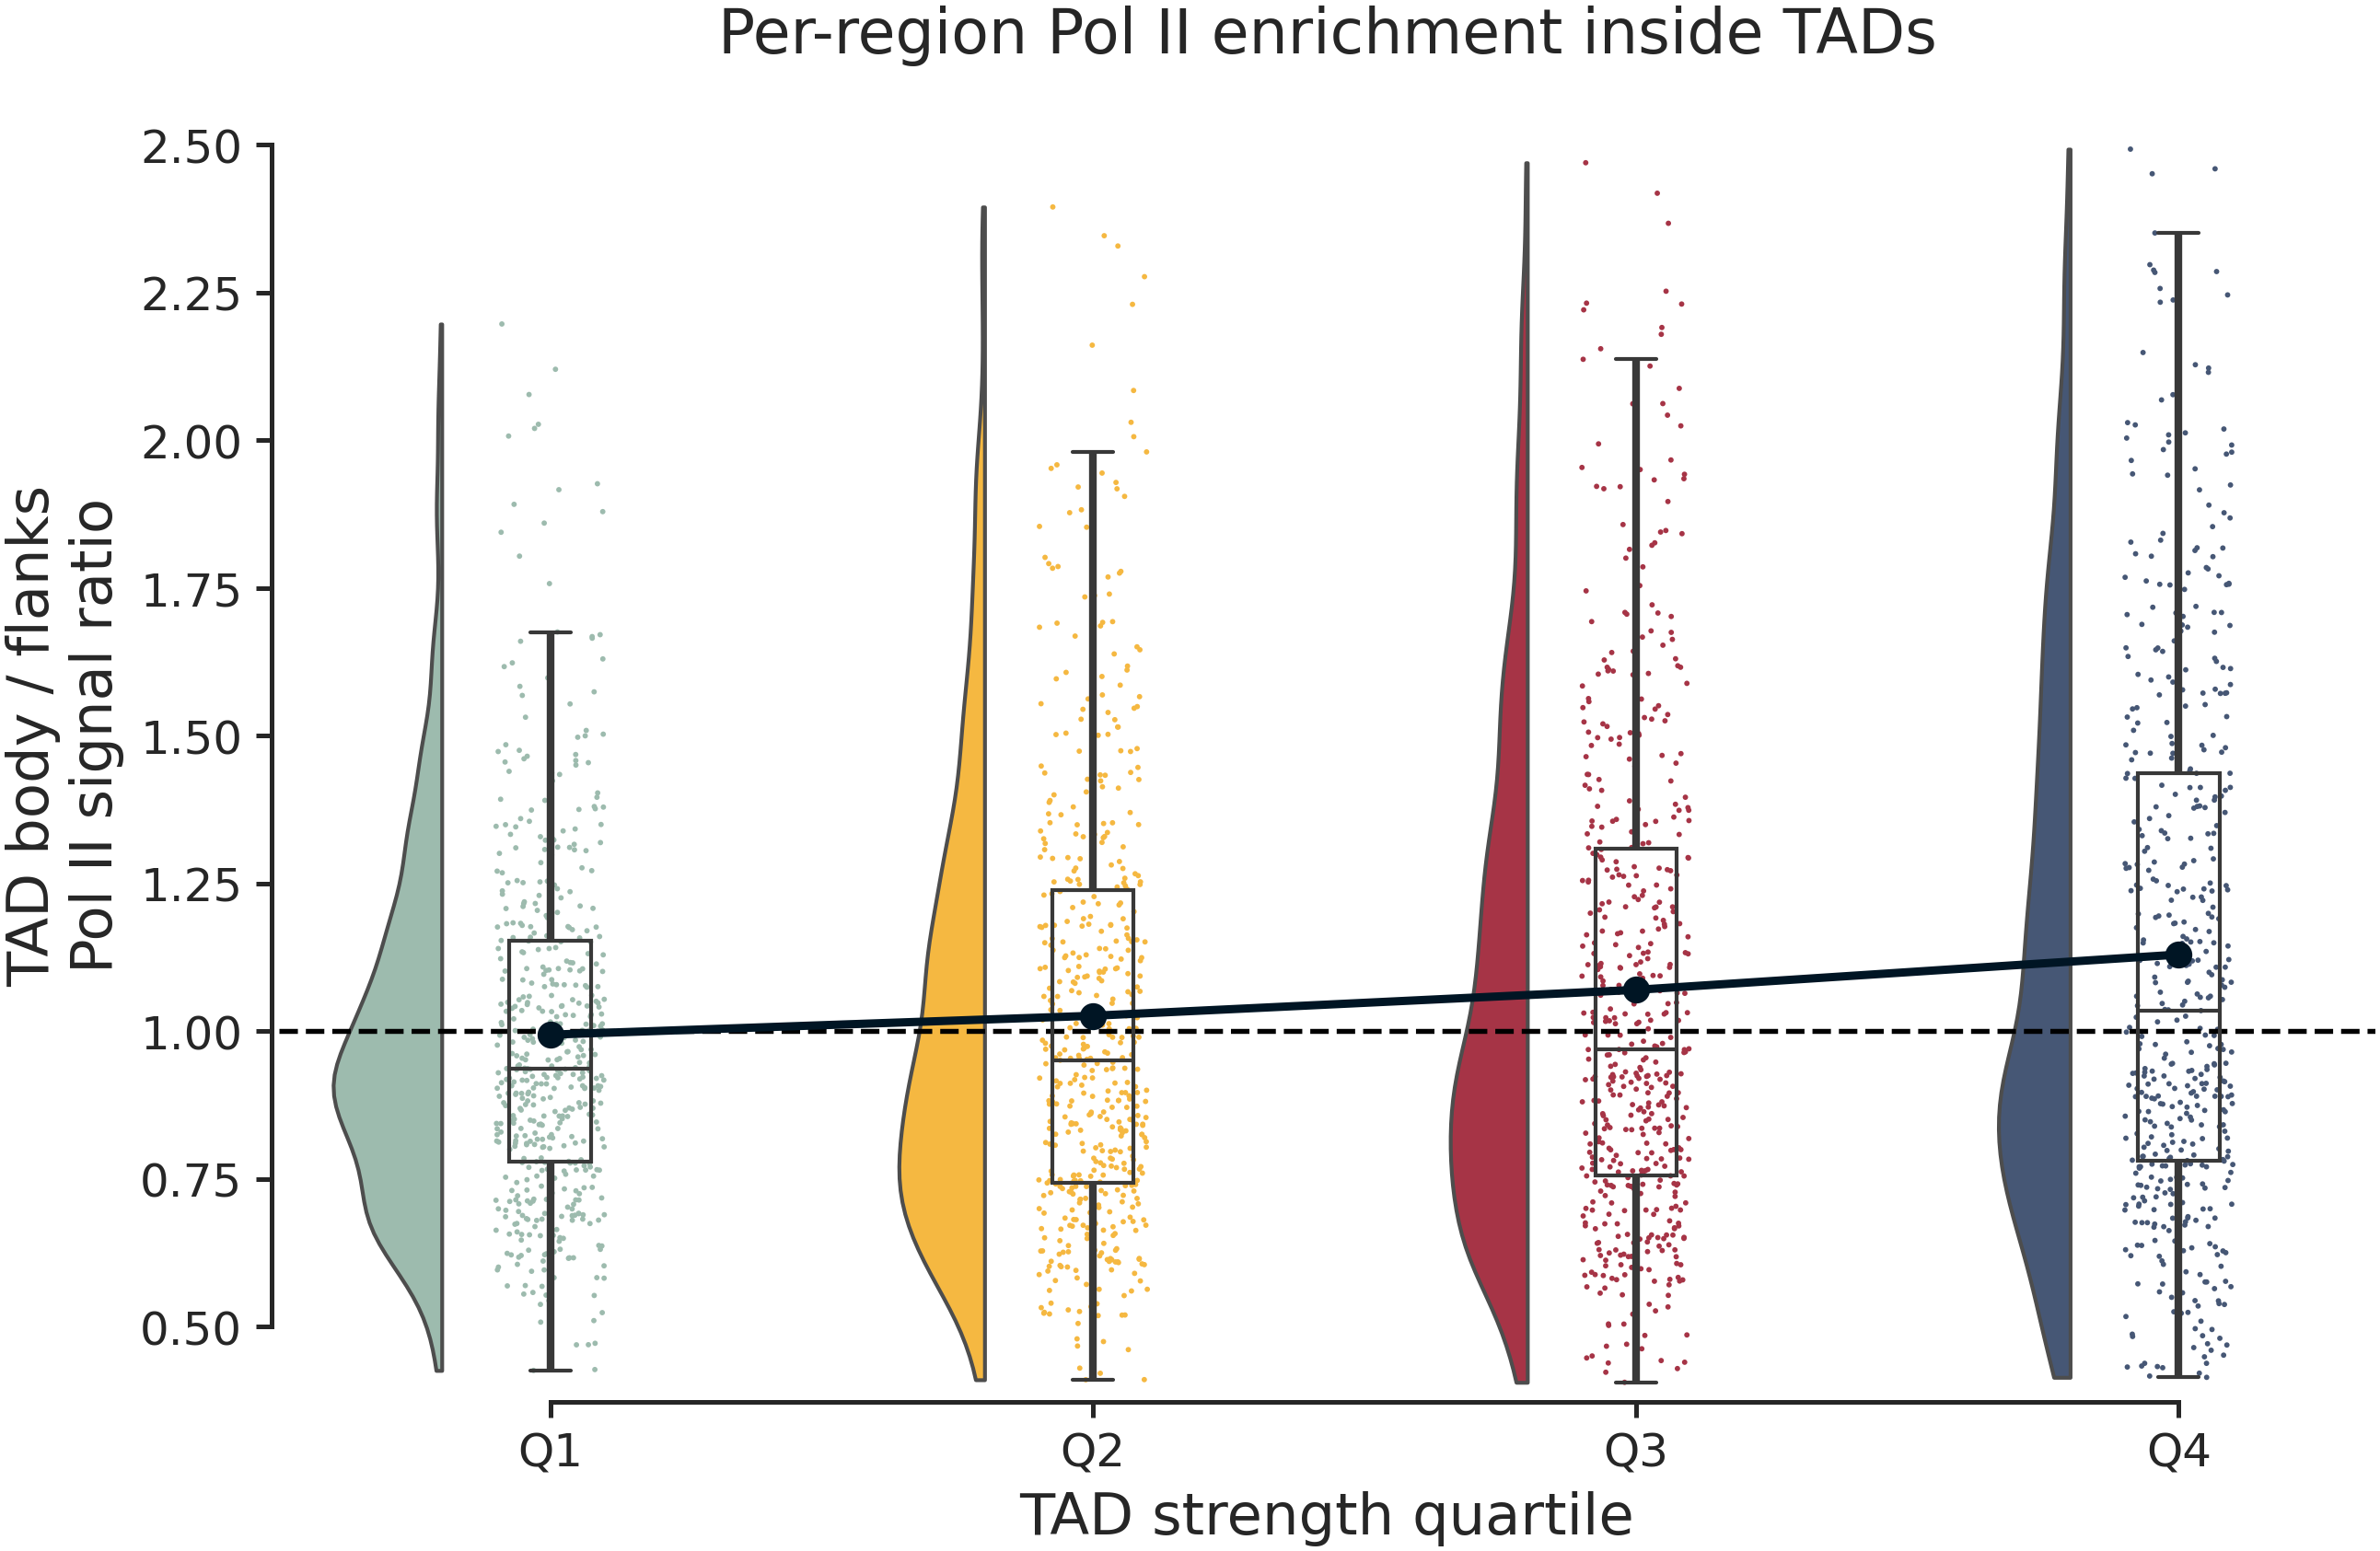

In [23]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import ptitprince as pt

from ggner_3d import plotting

# ----------------------------
# Plot config
# ----------------------------
ratio_col = "body_to_flanks_ratio"
order = ["Q1", "Q2", "Q3", "Q4"]
pal = list(reversed(plotting.COLORS))

plot_df = ratio_df[np.isfinite(ratio_df[ratio_col])].copy()

# Clip 1st-99th percentiles for visualization only
p1, p99 = np.nanpercentile(plot_df[ratio_col], [1, 99])
plot_df_clipped = plot_df.loc[
    plot_df[ratio_col].between(p1, p99, inclusive="both")
].copy()

# ----------------------------
# Style
# ----------------------------
plotting.update_rcparams()

mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 13,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
})

# ----------------------------
# Raincloud plot
# ----------------------------
fig, ax = plt.subplots(figsize=(9, 6))

pt.RainCloud(
    x="ds_Q_label",
    y=ratio_col,
    data=plot_df_clipped,
    order=order,
    palette=pal,
    bw=0.2,
    width_viol=0.4,
    ax=ax,
    orient="v",
    move=0.0,
    pointplot=True,
    point_size=1.4,
    linecolor="#001524",
    box_showfliers=False,
)

ax.axhline(1.0, color="black", linestyle="--", linewidth=1.3)

ax.set_xlabel("TAD strength quartile")
ax.set_ylabel("TAD body / flanks\nPol II signal ratio")
ax.set_title("Per-region Pol II enrichment inside TADs")

ax.set_ylim(
    plot_df_clipped[ratio_col].min() * 0.95,
    plot_df_clipped[ratio_col].max() * 1.05,
)

plotting.despine(ax)
fig.tight_layout()

fig.savefig(
    "/home/carlos/Clone/ggner-3d/data/degron_pol2/"
    "dld1_pol2_tad_q_body_to_flanks_ratio_raincloud_flank1_clipped.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    "/home/carlos/Clone/ggner-3d/data/degron_pol2/"
    "dld1_pol2_tad_q_body_to_flanks_ratio_raincloud_flank1_clipped.svg",
    dpi=300,
    bbox_inches="tight",
)
